<img src="../Decorative-Elements/Section-03/Section-03-04/Section-03-04-04.png">
<p style="display: flex; justify-content: space-between;">
  <a href="../03-Solar-System/04-Moon-Orbits-of-Each-Planet-03.ipynb" target="_blank">Previous</a>
  <a href="../03-Solar-System/04-Moon-Orbits-of-Each-Planet-05.ipynb" target="_blank">Next</a>
</p>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go

In [2]:
# Planet: Mars

# Average distance from Sun: 1.52 AU
# Orbital period around Sun: 1.88 Earth years
# Orbital period in days: 687 days
# Total number of moons: 2

# Years represent the full orbital revolution of Mars around the Sun.
# 1.88 years is equivalent to 687 days.

# Moon: Phobos
# Mean orbital distance from Mars: 9,376 km
# Orbital period: 7.66 hours

# Moon: Deimos
# Mean orbital distance from Mars: 23,463 km
# Orbital period: 30.35 hours

# Phobos revolves faster than Deimos because its orbital period is shorter.

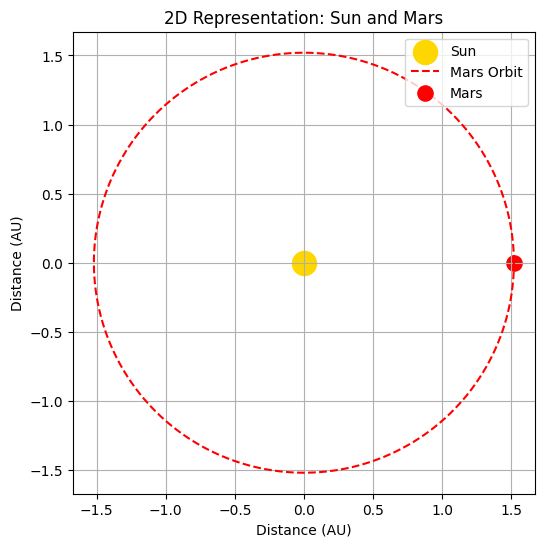

In [3]:
mars_radius = 1.52  

theta = np.linspace(0, 2*np.pi, 400)

x_orbit = mars_radius * np.cos(theta)
y_orbit = mars_radius * np.sin(theta)

plt.figure(figsize=(6,6))

# Sun
plt.scatter(0, 0, s=300, color='gold', label='Sun')

# Mars orbit
plt.plot(x_orbit, y_orbit, linestyle='--', color='red', label='Mars Orbit')

# Mars position
plt.scatter(mars_radius, 0, s=120, color='red', label='Mars')

plt.gca().set_aspect('equal', 'box')
plt.title("2D Representation: Sun and Mars")
plt.xlabel("Distance (AU)")
plt.ylabel("Distance (AU)")
plt.legend(loc='upper right')
plt.grid(True)

plt.show()

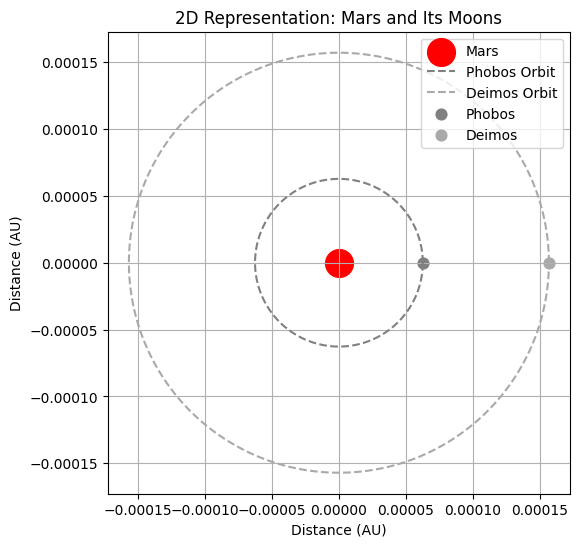

In [4]:
# Orbital radii in AU
phobos_radius = 6.27e-5
deimos_radius = 1.57e-4

theta = np.linspace(0, 2*np.pi, 400)

# Orbits
x_phobos = phobos_radius * np.cos(theta)
y_phobos = phobos_radius * np.sin(theta)

x_deimos = deimos_radius * np.cos(theta)
y_deimos = deimos_radius * np.sin(theta)

plt.figure(figsize=(6,6))

# Mars at center
plt.scatter(0, 0, s=400, color='red', label='Mars')

# Orbits
plt.plot(x_phobos, y_phobos, linestyle='--', color='gray', label='Phobos Orbit')
plt.plot(x_deimos, y_deimos, linestyle='--', color='darkgray', label='Deimos Orbit')

# Example moon positions
plt.scatter(phobos_radius, 0, s=60, color='gray', label='Phobos')
plt.scatter(deimos_radius, 0, s=60, color='darkgray', label='Deimos')

plt.gca().set_aspect('equal', 'box')
plt.title("2D Representation: Mars and Its Moons")
plt.xlabel("Distance (AU)")
plt.ylabel("Distance (AU)")
plt.legend(loc='upper right')
plt.grid(True)

plt.show()

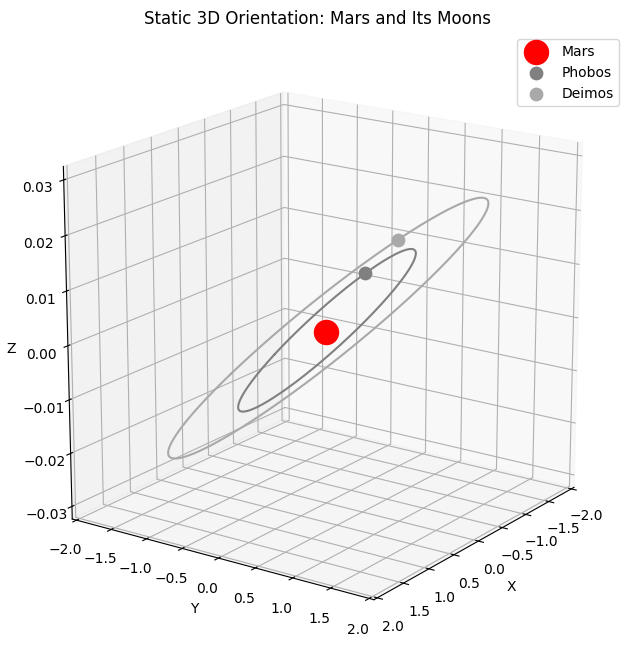

In [5]:
# (Scaled radius, inclination in degrees, color)
moon_data = {
    "Phobos": (1.0, 1.0, "gray"),
    "Deimos": (1.8, 0.9, "darkgray")
}

theta = np.linspace(0, 2*np.pi, 600)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# Mars at origin
ax.scatter(0, 0, 0, s=300, color='red', label='Mars')

for moon, (radius, inc_deg, color) in moon_data.items():

    inc = np.radians(inc_deg)

    # Base orbit (xy-plane)
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    z = np.zeros_like(theta)

    # Incline orbit about x-axis
    y_rot = y * np.cos(inc)
    z_rot = y * np.sin(inc)

    ax.plot(x, y_rot, z_rot, color=color)

    # Place moon at 60° so inclination is visible
    angle = np.pi / 3
    moon_x = radius * np.cos(angle)
    moon_y = radius * np.sin(angle) * np.cos(inc)
    moon_z = radius * np.sin(angle) * np.sin(inc)

    ax.scatter(moon_x, moon_y, moon_z, s=80, color=color, label=moon)

ax.set_title("Static 3D Orientation: Mars and Its Moons")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_box_aspect([1,1,1])
ax.view_init(elev=18, azim=35)

ax.legend(loc="upper right")

plt.show()

In [6]:
# Moon data: (scaled radius, inclination in degrees, color)
moon_data = {
    "Phobos": (1.0, 1.0, "gray"),
    "Deimos": (1.8, 0.9, "darkgray")
}

theta = np.linspace(0, 2*np.pi, 600)

# Plotly Figure
fig = go.Figure()

# Mars at origin
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers',
    marker=dict(size=15, color='red'),
    name='Mars'
))

for moon, (radius, inc_deg, color) in moon_data.items():
    
    inc = np.radians(inc_deg)
    
    # Base circular orbit in xy-plane
    x = radius * np.cos(theta)
    y_base = radius * np.sin(theta)
    z_base = np.zeros_like(theta)
    
    # Rotate orbit to add inclination
    y_rot = y_base * np.cos(inc)
    z_rot = y_base * np.sin(inc)
    
    # Plot orbit
    fig.add_trace(go.Scatter3d(
        x=x, y=y_rot, z=z_rot,
        mode='lines',
        line=dict(color=color, width=2),
        name=f'{moon} Orbit'
    ))
    
    # Place moon at 60° along orbit for visibility
    angle = np.pi / 3
    moon_x = radius * np.cos(angle)
    moon_y = radius * np.sin(angle) * np.cos(inc)
    moon_z = radius * np.sin(angle) * np.sin(inc)
    
    fig.add_trace(go.Scatter3d(
        x=[moon_x], y=[moon_y], z=[moon_z],
        mode='markers',
        marker=dict(size=6, color=color),
        name=moon
    ))

# Layout
fig.update_layout(
    title="Static 3D Orientation: Mars and Its Moons",
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data'
    ),
    width=800,
    height=800,
    showlegend=True
)

fig.show()

# Output is not visible in github webpage, refer to Folder/Output-Plotly

<p style="display: flex; justify-content: space-between;">
  <a href="../03-Solar-System/04-Moon-Orbits-of-Each-Planet-03.ipynb" target="_blank">Previous</a>
  <a href="../03-Solar-System/04-Moon-Orbits-of-Each-Planet-05.ipynb" target="_blank">Next</a>
</p>

<img src="../Decorative-Elements/Section-Footer-Animated/Section-03-04/Section-03-04-d.gif">